# Real-Time Sliding-Window ECG Processing and PQRST Delineation

**Architecture:** Ring buffer + overlapping sliding-window processing
**Input:** Live ECG serial sensor stream (pyserial)
**Output:** Continuous PQRST detection, beat tables, CSV logs, live plots

This notebook is organised in two parts, mirroring the original batch pipeline:

| Part | Scope |
|------|-------|
| **Part 1 — Sections 1-6** | Streaming acquisition, ring buffer, real-time preprocessing, signal-quality checks |
| **Part 2 — Sections 7-13** | Streaming R-peak detection, PQRST delineation, tables, plots, CSV export |

**Section 19** contains the main real-time loop that unifies both parts into a single continuous pipeline.

# Section 0 — Safety and Scope Notice

## IMPORTANT DISCLAIMER

This notebook is provided strictly for engineering research and educational
purposes. It is NOT a certified medical device and must NOT be used for
clinical diagnosis, treatment decisions, patient monitoring, or any
medical application.

- pyserial    — reads byte-stream data from the hardware sensor over a COM / USB-serial port
- numpy       — numerical array operations, circular buffer backend
- scipy       — digital filter design (butter, sosfilt, iirnotch, sosfiltfilt), peak finding
- matplotlib  — real-time and publication-quality plotting
- pandas      — tabular summary output and CSV export

In [67]:
!pip install pyserial scipy numpy matplotlib pandas --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import sys
import time
import warnings

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

import serial  # pyserial

from scipy.signal import (
    butter, sosfilt, sosfilt_zi, sosfiltfilt,
    iirnotch, lfilter, lfilter_zi,
    find_peaks, welch
)

from scipy.ndimage import uniform_filter1d, median_filter

import pandas as pd

from IPython.display import clear_output, display

warnings.filterwarnings("ignore")

# ── Matplotlib style — publication quality ─────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "grid.alpha": 0.4,
    "lines.linewidth": 0.9,
    "font.family": "DejaVu Sans",
})

print("✓ All imports successful.")
print(f" Python  : {sys.version.split()[0]}")
print(f" numpy   : {np.__version__}")
print(f" scipy   : {__import__('scipy').__version__}")
print(f" pandas  : {pd.__version__}")
print(f" pyserial: {serial.__version__}")

✓ All imports successful.
 Python  : 3.10.11
 numpy   : 2.2.6
 scipy   : 1.15.3
 pandas  : 2.3.3
 pyserial: 3.5


# Section 2 — Configuration

*** Modify ALL parameters in this cell to match your hardware before running the notebook. ***

| Parameter group | Key settings |
|----------------|--------------|
| Serial port | COM port, baud rate, timeout |
| Sensor | Sampling rate, ADC conversion |
| Streaming architecture | Buffer duration, window duration, step duration |
| Filters | Powerline freq, notch Q, bandpass cutoffs/order |
| Detection | Threshold fraction, refractory period, adaptive params |

In [69]:
# ============================================
#      CONFIGURATION — EDIT THIS CELL
# ============================================

# ── Serial port settings ───────────────────────────────────

COM_PORT = "COM6"          # Windows: "COM3", "COM6", ...
                           # Linux / macOS: "/dev/ttyUSB0", "/dev/ttyACM0"

BAUD_RATE = 115200         # Must match firmware baud rate

SERIAL_TIMEOUT = 2         # Read timeout in seconds


# ── Sensor / sampling settings ─────────────────────────────

FS = 100                   # Sampling frequency in Hz
                           # Common: 100, 250, 360, 500, 1000 Hz


# ── ADC conversion (set ENABLE_ADC_CONVERSION = True if sensor sends raw counts)

ENABLE_ADC_CONVERSION = False

ADC_BITS = 10              # ADC resolution (e.g. 10 for Arduino Uno)

ADC_VREF_MV = 3300.0       # Full-scale ADC reference voltage in mV

ADC_OFFSET_MV = 1650.0     # DC offset to subtract (mid-rail for single-supply)


# ── Streaming architecture ────────────────────────────────

BUFFER_DURATION_S = 30     # Ring buffer stores this many seconds

WINDOW_DURATION_S = 10     # Processing window length in seconds

STEP_DURATION_S = 1        # New processing triggered every this many seconds

OVERLAP_DURATION_S = WINDOW_DURATION_S - STEP_DURATION_S

# ── Preprocessing / filter settings ───────────────────────

POWERLINE_FREQ = 50        # 50 Hz (India/Europe/Asia) or 60 Hz (N. America)

NOTCH_Q = 30              # Notch quality factor

BP_LOW = 0.5             # Bandpass lower cutoff (Hz)

BP_HIGH = 40.0           # Bandpass upper cutoff (Hz)

BP_ORDER = 4             # Butterworth filter order


# ── Detection settings ────────────────────────────────────

THRESHOLD_FRACTION = 0.40

MIN_RR_DISTANCE_S = 0.200

PROMINENCE_FRACTION = 0.30

ADAPTIVE_DECAY = 0.125

DUPLICATE_TOL_S = 0.080

Q_SEARCH_BEFORE_S = 0.005
Q_SEARCH_BEFORE_E = 0.080

S_SEARCH_AFTER_S = 0.005
S_SEARCH_AFTER_E = 0.100

P_BEFORE_R_END = 0.080
P_BEFORE_R_START = 0.250

T_AFTER_S_START = 0.080
T_AFTER_S_MAX = 0.450

T_BEFORE_NEXT_R = 0.100

BUFFER_SAMPLES = int(FS * BUFFER_DURATION_S)

WINDOW_SAMPLES = int(FS * WINDOW_DURATION_S)

STEP_SAMPLES = int(FS * STEP_DURATION_S)


print("Configuration loaded:")

print(f" Serial        : {COM_PORT} @ {BAUD_RATE} baud")
print(f" Sampling rate : {FS} Hz")

print(f" Buffer        : {BUFFER_DURATION_S} s ({BUFFER_SAMPLES} samples)")
print(f" Window        : {WINDOW_DURATION_S} s ({WINDOW_SAMPLES} samples)")
print(f" Step          : {STEP_DURATION_S} s ({STEP_SAMPLES} samples)")

print(f" Overlap       : {OVERLAP_DURATION_S} s")

print(f" Powerline notch : {POWERLINE_FREQ} Hz, Q={NOTCH_Q}")

print(f" Bandpass      : {BP_LOW}-{BP_HIGH} Hz, order={BP_ORDER}")

Configuration loaded:
 Serial        : COM6 @ 115200 baud
 Sampling rate : 100 Hz
 Buffer        : 30 s (3000 samples)
 Window        : 10 s (1000 samples)
 Step          : 1 s (100 samples)
 Overlap       : 9 s
 Powerline notch : 50 Hz, Q=30
 Bandpass      : 0.5-40.0 Hz, order=4


# Section 3 — Serial Parser and Acquisition Utilities

**Protocol assumption:**
The firmware sends **one numeric sample per line** terminated by '\n'.

Examples:

Arduino:
Serial.println(analogRead(A0));

AD8232:
Serial.println(ecgValue);

ADS1115:
Serial.println(voltage_mV, 4);

If your firmware sends CSV, JSON, or binary frames, modify
parse_sample() below.

No synthetic data is generated anywhere.
If the serial port cannot be opened, the notebook fails with a clear
diagnostic message.

In [70]:
def parse_sample(raw_line: bytes):
    """
    Decode one raw serial line into a float sample.
    """

    try:
        text = raw_line.decode("utf-8", errors="replace").strip()

        if not text:
            return None

        return float(text)

    except (ValueError, UnicodeDecodeError):
        return None
    
def adc_to_mv(raw_value):
    max_count = (2 ** ADC_BITS) - 1

    mv = (raw_value / max_count) * ADC_VREF_MV - ADC_OFFSET_MV

    return mv

def open_serial(port, baud, timeout):

    try:
        ser = serial.Serial(port, baud, timeout=timeout)

        time.sleep(0.5)

        ser.reset_input_buffer()

        print(f"✓ Serial port {port} opened at {baud} baud.")

        return ser

    except serial.SerialException as exc:

        print(f"\n[SerialException] Could not open {port}: {exc}")

        print("\nTroubleshooting:")

        print("1. Check COM PORT")
        print("2. Verify BAUD_RATE matches firmware")
        print("3. Ensure no other application holds the port")
        print("4. On Linux/macOS: sudo chmod a+rw /dev/ttyUSB0")
        print("5. Check USB cable")
        print("6. Verify the sensor is powered and the LED is blinking")

        raise

class SerialStats:
    """Tracks serial acquisition statistics in real time."""

    def __init__(self):

        self.total_received = 0
        self.total_dropped = 0
        self.total_errors = 0

        self.start_time = None
        self.last_sample_time = None

    def record_sample(self):

        now = time.time()

        if self.start_time is None:
            self.start_time = now

        self.last_sample_time = now

        self.total_received += 1

    def record_drop(self):
        self.total_dropped += 1

    def record_error(self):
        self.total_errors += 1

    @property
    def elapsed(self):

        if self.start_time is None:
            return 0.0

        return time.time() - self.start_time

    @property
    def effective_fs(self):

        if self.elapsed < 0.1 or self.total_received < 2:
            return 0.0

        return self.total_received / self.elapsed
    

    def summary(self):
        return (
            f"Samples: {self.total_received} | "
            f"Dropped: {self.total_dropped} | "
            f"Errors: {self.total_errors} | "
            f"Effective FS: {self.effective_fs:.1f} Hz | "
            f"Elapsed: {self.elapsed:.1f} s"
        )
print(
    "✓ Serial utilities defined: "
    "parse_sample(), adc_to_mv(), open_serial(), SerialStats"
)

✓ Serial utilities defined: parse_sample(), adc_to_mv(), open_serial(), SerialStats


# Section 4 — Ring Buffer Implementation

A fixed-size circular (ring) buffer that:

- Stores the most recent `BUFFER_DURATION_S` seconds of ECG data
- Supports appending one sample at a time (O(1) amortised)
- Returns the latest `WINDOW_DURATION_S` seconds as a contiguous NumPy array
- Returns an aligned time axis in seconds
- Handles index wrap-around correctly
- Never grows unbounded in memory — older samples are silently overwritten

The ring buffer is the backbone of the real-time architecture:
the serial reader pushes samples in, and the processing loop pulls windows out.

In [71]:
class RingBuffer:
    """
    Fixed-size circular buffer backed by a pre-allocated NumPy array.

    Parameters
    ----------
    capacity : int
        Maximum number of samples the buffer can hold.

    fs : float
        Sampling frequency in Hz (used for time-axis generation).
    """

    def __init__(self, capacity: int, fs: float):
        self._buf = np.zeros(capacity, dtype=np.float64)
        self._capacity = capacity
        self._fs = fs

        self._write_idx = 0      # Next position to write
        self._count = 0          # Total samples written (may exceed capacity)

    @property
    def capacity(self):
        return self._capacity

    @property
    def count(self):
        """Total number of samples appended (including overwritten ones)."""
        return self._count

    @property
    def filled(self):
        """Number of valid samples currently in the buffer."""
        return min(self._count, self._capacity)

    @property
    def is_full(self):
        return self._count >= self._capacity
    
    def append(self, sample: float):
        """Append a single sample. O(1) operation."""

        self._buf[self._write_idx] = sample

        self._write_idx = (self._write_idx + 1) % self._capacity

        self._count += 1
    def append_array(self, samples: np.ndarray):
        """Append multiple samples efficiently."""

        n = len(samples)

        if n == 0:
            return

        if n >= self._capacity:

            # Only keep the last capacity samples
            self._buf[:] = samples[-self._capacity:]

            self._write_idx = 0
            self._count += n

            return

        end = self._write_idx + n

        if end <= self._capacity:

            self._buf[self._write_idx:end] = samples

        else:

            first_part = self._capacity - self._write_idx

            self._buf[self._write_idx:] = samples[:first_part]

            self._buf[:n - first_part] = samples[first_part:]

        self._write_idx = end % self._capacity

        self._count += n

    def get_latest(self, n_samples: int) -> np.ndarray:
        """
        Return the most recent n_samples as a contiguous NumPy array.
        If fewer samples are available, returns all available samples.
        """

        available = self.filled

        n = min(n_samples, available)

        if n == 0:
            return np.array([], dtype=np.float64)

        start = (self._write_idx - n) % self._capacity

        if start + n <= self._capacity:

            return self._buf[start:start + n].copy()

        else:

            first_part = self._capacity - start

            return np.concatenate([
                self._buf[start:],
                self._buf[:n - first_part]
            ])
        
    def get_window(self, window_samples: int) -> np.ndarray:
        """Return the latest window_samples as a NumPy array."""
        return self.get_latest(window_samples)
    
    
    def get_time_axis(self, n_samples: int) -> np.ndarray:
        """
        Return a time axis (seconds) aligned with the latest n_samples.
        The most recent sample has the highest time value.
        """

        available = min(n_samples, self.filled)

        if available == 0:
            return np.array([], dtype=np.float64)

        # Global sample index of the most recent sample

        global_end = self._count

        global_start = global_end - available

        return np.arange(global_start, global_end) / self._fs   

    def get_global_offset(self, n_samples: int) -> int:
        """
        Return the global sample index of the first sample in the
        latest n_samples window. Used for converting window-local
        indices to global indices.
        """

        available = min(n_samples, self.filled)

        return self._count - available

    def fill_fraction(self) -> float:
        """Fraction of buffer capacity currently filled (0.0 to 1.0)."""

        return self.filled / self._capacity
    
# ── Quick self-test ─────────────────────────────────────

_rb_test = RingBuffer(capacity=10, fs=100.0)

for i in range(15):
    _rb_test.append(float(i))

assert _rb_test.filled == 10
assert _rb_test.count == 15

latest5 = _rb_test.get_latest(5)

assert np.array_equal(
    latest5,
    np.array([10., 11., 12., 13., 14.])
)

assert _rb_test.get_global_offset(5) == 10

del _rb_test

print("✓ RingBuffer class defined and self-test passed.")

print(
    f" Buffer capacity for this session: "
    f"{BUFFER_SAMPLES} samples ({BUFFER_DURATION_S} s)"
)

print(
    f" Window size: "
    f"{WINDOW_SAMPLES} samples ({WINDOW_DURATION_S} s)"
)

✓ RingBuffer class defined and self-test passed.
 Buffer capacity for this session: 3000 samples (30 s)
 Window size: 1000 samples (10 s)


# PART 1 — Real-Time ECG Acquisition and Preprocessing

## Section 5 — Real-Time Causal Filters

### Why causal filtering for live detection?

In a batch/offline pipeline, zero-phase filters (`sosfiltfilt`) are ideal
because they introduce no group delay and preserve waveform timing.

However, `sosfiltfilt` requires the **entire signal** — it processes forward
and backward.

In a **streaming** pipeline, future samples do not exist yet.

We must use **causal (forward-only)** filtering with persistent filter states
across successive samples/windows.

### Implementation

- **Mode A – Live causal mode**
  Uses `scipy.signal.sosfilt()` with persistent `zi` states.
  Used for all real-time detection.

- **Mode B – Diagnostic zero-phase mode**
  Uses `sosfiltfilt()` on a completed window.
  Used only for optional visualization and debugging.

### Filter chain (applied in order)

1. **Notch filter**
   Removes powerline interference (50 Hz or 60 Hz)

2. **Bandpass filter**
   Keeps ECG band (0.5–40 Hz)

3. **Baseline correction**
   High-pass action from bandpass plus optional rolling median subtraction

In [72]:
class RealtimeFilterBank:
    """
    Stateful causal filter bank for real-time ECG preprocessing.

    Maintains persistent filter states (zi) across calls so that
    consecutive windows/samples are filtered as a continuous stream
    without transient artefacts at window boundaries.

    Filter chain:

        1. IIR Notch at POWERLINE_FREQ Hz (2nd-order)
        2. Butterworth bandpass BP_LOW–BP_HIGH Hz
           (BP_ORDER-th order, SOS)
    """
    def __init__(
        self,
        fs,
        powerline_freq=50,
        notch_q=30,
        bp_low=0.5,
        bp_high=40.0,
        bp_order=4,
    ):

        self.fs = fs

        # ── Notch filter ─────────────────────────────

        b_notch, a_notch = iirnotch(
            powerline_freq,
            notch_q,
            fs
        )

        self._notch_b = b_notch
        self._notch_a = a_notch

        self._notch_zi_template = lfilter_zi(
            b_notch,
            a_notch
        )

        self._notch_zi = self._notch_zi_template.copy()

        # ── Bandpass filter ──────────────────────────

        nyq = fs / 2.0

        low_norm = bp_low / nyq
        high_norm = bp_high / nyq

        low_norm = max(low_norm, 1e-6)
        high_norm = min(high_norm, 1.0 - 1e-6)

        self._bp_sos = butter(
            bp_order,
            [low_norm, high_norm],
            btype="bandpass",
            output="sos"
        )

        self._bp_zi_template = sosfilt_zi(self._bp_sos)

        self._bp_zi = self._bp_zi_template.copy()

        # ── Rolling baseline state ──────────────────

        self._baseline_buf = []

        self._baseline_window = max(
            1,
            int(0.6 * fs)
        )  # 600 ms rolling median

        print(" Filter bank initialised:")

        print(
            f"   Notch    : {powerline_freq} Hz, Q={notch_q}"
        )

        print(
            f"   Bandpass : {bp_low}-{bp_high} Hz, "
            f"order {bp_order} (SOS)"
        )

        print(
            f"   Baseline : rolling median window "
            f"= {self._baseline_window} samples"
        )

    def reset(self):
        """Reset all filter states to initial conditions."""

        self._notch_zi = self._notch_zi_template.copy()

        self._bp_zi = self._bp_zi_template.copy()

        self._baseline_buf = []

    def process_chunk(
        self,
        chunk: np.ndarray
    ) -> np.ndarray:
        """
        Process a chunk of samples through the full
        causal filter chain.

        Filter states are updated in-place for
        seamless streaming.
        """

        # Step 1: Notch filter

        notched, self._notch_zi = lfilter(
            self._notch_b,
            self._notch_a,
            chunk,
            zi=self._notch_zi
        )

        # Step 2: Bandpass filter

        bandpassed, self._bp_zi = sosfilt(
            self._bp_sos,
            notched,
            zi=self._bp_zi
        )

        return bandpassed
    
    def process_sample(
        self,
        sample: float
    ) -> float:
        """Process a single sample through the filter chain."""

        result = self.process_chunk(
            np.array([sample])
        )

        return float(result[0])
    
    @staticmethod
    def process_window_diagnostic(
        window: np.ndarray,
        fs: float,
        powerline_freq=50,
        notch_q=30,
        bp_low=0.5,
        bp_high=40.0,
        bp_order=4,
    ):
        """
        DIAGNOSTIC / OFFLINE ONLY

        Zero-phase filtering of a completed window.
        """
        b_n, a_n = iirnotch(
            powerline_freq,
            notch_q,
            fs
        )

        from scipy.signal import filtfilt

        notched = filtfilt(
            b_n,
            a_n,
            window
        )

        nyq = fs / 2.0

        sos_bp = butter(
            bp_order,
            [
                max(bp_low / nyq, 1e-6),
                min(bp_high / nyq, 1.0 - 1e-6)
            ],
            btype="bandpass",
            output="sos"
        )

        bandpassed = sosfiltfilt(
            sos_bp,
            notched
        )
        from scipy.signal import medfilt

        k1 = int(0.2 * fs) | 1
        k2 = int(0.6 * fs) | 1

        if k1 > 3 and len(bandpassed) > k1:

            baseline = medfilt(
                bandpassed,
                kernel_size=k1
            )

            if k2 > 3 and len(baseline) > k2:

                baseline = medfilt(
                    baseline,
                    kernel_size=k2
                )

            bandpassed = bandpassed - baseline

        return bandpassed
    
    
print("✓ RealtimeFilterBank class defined.")

print(
    " Modes: process_chunk() [causal/live], "
    "process_window_diagnostic() [zero-phase/offline]"
)

✓ RealtimeFilterBank class defined.
 Modes: process_chunk() [causal/live], process_window_diagnostic() [zero-phase/offline]


## Section 6 — Signal Quality Metrics

Before and during detection, we compute real signal-quality metrics for each processed window.

These metrics serve two purposes:

1. **Gate** — decide whether the window quality is sufficient for peak detection
2. **Diagnose** — if detection fails, explain *why* using quantitative evidence

Metrics computed:

- Amplitude range / peak-to-peak
- RMS power
- Baseline level (mean)
- Estimated SNR (signal band vs. noise band power ratio)
- Saturation / clipping check
- Effective sampling rate

All values are computed from **real sensor data only**.

In [73]:
def compute_window_quality(window: np.ndarray, fs: float) -> dict:
    """
    Compute signal-quality metrics for a processing window.

    Parameters
    ----------
    window : np.ndarray
        ECG samples (filtered or raw).

    fs : float
        Sampling frequency in Hz.

    Returns
    -------
    dict
        Quality metrics with keys:
        amplitude_range, rms, baseline_level,
        peak_to_peak, snr_db, is_clipped,
        n_clipped_samples, duration_s, n_samples.
    """

    n = len(window)

    if n == 0:
        return {
            "amplitude_range": (0, 0),
            "rms": 0,
            "baseline_level": 0,
            "peak_to_peak": 0,
            "snr_db": 0,
            "is_clipped": False,
            "n_clipped_samples": 0,
            "duration_s": 0,
            "n_samples": 0,
        }

    sig_min = float(np.min(window))
    sig_max = float(np.max(window))

    p2p = sig_max - sig_min

    rms_val = float(np.sqrt(np.mean(window ** 2)))

    mean_val = float(np.mean(window))

    # SNR estimate: signal band power vs noise proxy
    # Signal: std of the window (dominated by ECG if clean)
    # Noise proxy: high-frequency residual above BP_HIGH
    # Simplified: use ratio of low-freq to high-freq energy

    snr_db = 0.0

    try:

        if n > 16:

            freqs, psd = welch(
                window,
                fs=fs,
                nperseg=min(256, n)
            )

            sig_mask = (freqs >= 0.5) & (freqs <= 40.0)

            noise_mask = freqs > 40.0

            if np.any(sig_mask) and np.any(noise_mask):

                sig_power = np.trapz(
                    psd[sig_mask],
                    freqs[sig_mask]
                )

                noise_power = np.trapz(
                    psd[noise_mask],
                    freqs[noise_mask]
                )

                if noise_power > 0:

                    snr_db = 10 * np.log10(
                        sig_power / noise_power
                    )

    except Exception:

        snr_db = 0.0

    # Clipping check: samples at extreme values

    if p2p > 0:

        clip_thresh = 0.01 * p2p

        n_clipped = int(np.sum(
            (window <= sig_min + clip_thresh) |
            (window >= sig_max - clip_thresh)
        ))

        # Only flag if significant fraction is clipped

        is_clipped = (n_clipped / n) > 0.05

    else:

        n_clipped = n

        is_clipped = True

    return {

        "amplitude_range": (sig_min, sig_max),

        "rms": rms_val,

        "baseline_level": mean_val,

        "peak_to_peak": p2p,

        "snr_db": snr_db,

        "is_clipped": is_clipped,

        "n_clipped_samples": n_clipped,

        "duration_s": n / fs,

        "n_samples": n,
    }


def diagnose_detection_failure(
    quality: dict,
    n_peaks: int,
    fs: float,
    window_samples: int,
) -> str:
    """
    Generate a diagnostic message explaining why peak detection
    may have failed or produced few results.

    Returns
    -------
    str
        Multi-line diagnostic message.
    """

    issues = []

    p2p = quality["peak_to_peak"]
    rms = quality["rms"]
    snr = quality["snr_db"]
    baseline = quality["baseline_level"]
    is_clipped = quality["is_clipped"]
    duration = quality["duration_s"]

    if p2p < 1e-6:

        issues.append(
            "Signal is FLAT (peak-to-peak ≈ 0). Sensor may be disconnected."
        )

    elif p2p < 0.05:

        issues.append(
            f"Very low amplitude (p2p={p2p:.4f}). "
            f"Possible: ADC counts not converted to mV, "
            f"or electrode contact is poor."
        )

    elif p2p > 20.0:

        issues.append(
            f"Very large amplitude (p2p={p2p:.2f}). "
            f"Possible: raw ADC counts, "
            f"or severe motion artefact."
        )

    if snr < 5:

        issues.append(
            f"Very low SNR ({snr:.1f} dB). "
            f"Signal may be buried in noise."
        )

    elif snr < 10:

        issues.append(
            f"Marginal SNR ({snr:.1f} dB). "
            f"Detection may be unreliable."
        )

    if is_clipped:

        issues.append(
            "Signal appears CLIPPED (>5% of samples at rail). "
            "Check ADC range / amplifier gain."
        )

    if abs(baseline) > 0.5 * rms and rms > 0:

        issues.append(
            f"Large baseline offset ({baseline:.4f}). "
            f"Baseline removal may be insufficient."
        )

    if duration < 2.0:

        issues.append(
            f"Window too short ({duration:.1f} s). "
            f"Need ≥2 s for reliable detection."
        )

    expected_min = max(1, int(0.4 * duration))   # 40 BPM
    expected_max = int(3.5 * duration)           # 210 BPM

    if n_peaks == 0:

        issues.append(
            "ZERO peaks detected. Threshold may be too high, "
            "or no QRS morphology present."
        )

    elif n_peaks < expected_min:

        issues.append(
            f"Too few peaks ({n_peaks}), expected ≥{expected_min} "
            f"for {duration:.0f}s window. "
            f"Possible bradycardia, missed beats, "
            f"or threshold too strict."
        )

    elif n_peaks > expected_max:

        issues.append(
            f"Too many peaks ({n_peaks}), expected ≤{expected_max}. "
            f"Possible noise spikes misclassified as R peaks."
        )

    if not issues:
        return (
            "No issues detected — signal quality appears adequate."
        )

    return (
        "Detection diagnostics:\n"
        + "\n".join(f" • {iss}" for iss in issues)
    )


print(
    "✓ Signal quality functions defined: "
    "compute_window_quality(), diagnose_detection_failure()"
)

✓ Signal quality functions defined: compute_window_quality(), diagnose_detection_failure()


## Section 7 — Pan-Tompkins Real-Time R-Peak Detector

### Algorithm summary (Pan & Tompkins, IEEE TBME, 1985):

1. **Differentiate** — five-point derivative `[-1, -2, 0, 2, 1] / 8`
   emphasizes steep QRS slopes

2. **Square** — rectifies sign and amplifies large slopes

3. **Moving-window integrate** — 150 ms window smooths QRS into a
   single hump

4. **Adaptive threshold** — tracks signal peak level and noise peak
   level separately

### Adaptive thresholding strategy

This implementation uses a **three-tier fallback** to avoid the failure
mode where **"no peaks are detected"**.

| Tier | Method | Description |
|------|---------|-------------|
| 1 | Pan-Tompkins signal/noise tracking | `threshold = noise_level + 0.25 * (signal_level - noise_level)` |
| 2 | Rolling percentile | 85th–95th percentile of integrated signal |
| 3 | Median + k × MAD | `threshold = median + 2.5 * MAD` of integrated signal |

If tier 1 produces too few peaks, the detector automatically falls back
to tier 2, then tier 3.

### Additional robustness

- **Refractory period** (200–250 ms) prevents double-detection
- **Inverted polarity** detection and correction
- **Local refinement** on cleaned ECG (not integrated signal)
- **Prominence check** rejects flat plateaus

In [74]:
class RealtimeRPeakDetector:
    """
    Adaptive Pan-Tompkins-inspired R-peak detector for streaming windows.

    Maintains signal_level and noise_level across windows for continuous
    adaptive thresholding.
    """

    def __init__(self, fs: float):
        self.fs = fs
        self.signal_level = None
        self.noise_level = None
        self.threshold = None
        self.decay = ADAPTIVE_DECAY
        self.min_distance = max(1, int(MIN_RR_DISTANCE_S * fs))
        self.integration_window = max(3, round(0.150 * fs))
        self._polarity_votes = []

    def _pan_tompkins_transform(self, ecg_window: np.ndarray):
        """
        Apply the Pan-Tompkins transformation chain.

        Returns
        -------
        ecg_diff : np.ndarray
        ecg_sq : np.ndarray
        ecg_integrated : np.ndarray
        """

        diff_kernel = np.array([-1, -2, 0, 2, 1],
                               dtype=np.float64) / 8.0

        ecg_diff = np.convolve(
            ecg_window,
            diff_kernel,
            mode="same"
        )

        ecg_sq = ecg_diff ** 2

        ecg_integrated = uniform_filter1d(
            ecg_sq,
            size=self.integration_window
        )

        return ecg_diff, ecg_sq, ecg_integrated

    def _detect_polarity(self, ecg_window: np.ndarray) -> bool:
        """
        Detect if ECG is inverted.
        Returns True if signal should be flipped.
        """

        abs_max = np.max(ecg_window)
        abs_min = np.min(ecg_window)

        top_pct = np.percentile(ecg_window, 98)
        bot_pct = np.percentile(ecg_window, 2)

        is_inverted = abs(bot_pct) > abs(top_pct) * 1.2

        return is_inverted

    def _tier1_pan_tompkins_threshold(self,
                                      integrated,
                                      peaks_idx):
        """
        Tier 1: Classic Pan-Tompkins adaptive
        signal/noise level tracking.
        """

        for p_idx in peaks_idx:

            p_val = integrated[p_idx]

            if self.threshold is not None and p_val > self.threshold:

                if self.signal_level is None:
                    self.signal_level = p_val
                else:
                    self.signal_level = (
                        (1 - self.decay) * self.signal_level
                        + self.decay * p_val
                    )

            else:

                if self.noise_level is None:
                    self.noise_level = p_val
                else:
                    self.noise_level = (
                        (1 - self.decay) * self.noise_level
                        + self.decay * p_val
                    )

        if self.signal_level is not None and self.noise_level is not None:
            self.threshold = (
                self.noise_level
                + 0.25 * (self.signal_level - self.noise_level)
            )

        elif self.signal_level is not None:
            self.threshold = 0.40 * self.signal_level

    def detect_in_window(
        self,
        ecg_clean_window: np.ndarray,
        global_offset: int
    ) -> list:
        """
        Detect R peaks in a processing window.
        """

        n = len(ecg_clean_window)

        if n < self.min_distance * 2:
            return []

        # Check and correct polarity
        ecg_work = ecg_clean_window.copy()

        if self._detect_polarity(ecg_work):
            ecg_work = -ecg_work

        # Pan-Tompkins transform
        ecg_diff, ecg_sq, ecg_integrated = (
            self._pan_tompkins_transform(ecg_work)
        )

        # Initial threshold
        if self.threshold is None:
            self.signal_level = np.percentile(
                ecg_integrated,
                95
            )

            self.noise_level = np.percentile(
                ecg_integrated,
                50
            )

            self.threshold = (
                self.noise_level
                + 0.25 * (
                    self.signal_level
                    - self.noise_level
                )
            )

        # Tier 1
        tier1_peaks, _ = find_peaks(
            ecg_integrated,
            height=self.threshold,
            distance=self.min_distance,
            prominence=max(
                self.threshold * PROMINENCE_FRACTION,
                1e-12
            )
        )

        self._tier1_pan_tompkins_threshold(
            ecg_integrated,
            tier1_peaks
        )

        duration_s = n / self.fs

        min_expected = max(
            1,
            int(0.4 * duration_s)
        )

        max_expected = int(
            3.5 * duration_s
        )

        detected_peaks = tier1_peaks
        tier_used = 1

        # Tier 2 fallback
        if len(detected_peaks) < min_expected:

            pct_thresh = np.percentile(
                ecg_integrated,
                90
            )

            tier2_peaks, _ = find_peaks(
                ecg_integrated,
                height=pct_thresh,
                distance=self.min_distance,
                prominence=max(
                    pct_thresh * 0.15,
                    1e-12
                )
            )

            if min_expected <= len(tier2_peaks) <= max_expected:

                detected_peaks = tier2_peaks
                tier_used = 2

            elif len(tier2_peaks) > len(detected_peaks):

                pct_thresh85 = np.percentile(
                    ecg_integrated,
                    85
                )

                tier2b_peaks, _ = find_peaks(
                    ecg_integrated,
                    height=pct_thresh85,
                    distance=self.min_distance,
                    prominence=max(
                        pct_thresh85 * 0.10,
                        1e-12
                    )
                )

                if len(tier2b_peaks) >= min_expected:
                    detected_peaks = tier2b_peaks
                    tier_used = 2

        # Tier 3 fallback
        if len(detected_peaks) < min_expected:

            med_val = np.median(
                ecg_integrated
            )

            mad_val = np.median(
                np.abs(
                    ecg_integrated
                    - med_val
                )
            )

            if mad_val > 0:

                for k_factor in [2.5, 2.0, 1.5]:

                    mad_thresh = (
                        med_val
                        + k_factor
                        * mad_val
                        * 1.4826
                    )

                    tier3_peaks, _ = find_peaks(
                        ecg_integrated,
                        height=mad_thresh,
                        distance=self.min_distance
                    )

                    if len(tier3_peaks) >= min_expected:

                        detected_peaks = tier3_peaks
                        tier_used = 3
                        break

        # Clamp excessive detections
        if len(detected_peaks) > max_expected * 1.5:

            amps = ecg_integrated[
                detected_peaks
            ]

            top_n = max_expected

            top_indices = np.argsort(
                amps
            )[-top_n:]

            detected_peaks = np.sort(
                detected_peaks[top_indices]
            )

            tier_used = -1

        # Refine peak positions
        half_w = (
            self.integration_window // 2
            + 5
        )

        refined = []

        for idx in detected_peaks:

            lo = max(
                0,
                idx - half_w
            )

            hi = min(
                n - 1,
                idx + half_w
            )

            segment = ecg_work[
                lo:hi + 1
            ]

            if len(segment) == 0:
                continue

            local_max_idx = (
                lo + np.argmax(segment)
            )

            refined.append(
                local_max_idx
            )

        refined = sorted(
            set(refined)
        )

        final_peaks = []

        last_peak = (
            -self.min_distance - 1
        )

        for p in refined:

            if p - last_peak >= self.min_distance:
                final_peaks.append(p)
                last_peak = p

        results = []

        for local_idx in final_peaks:

            amp = float(
                ecg_clean_window[
                    local_idx
                ]
            )

            results.append({
                "global_idx":
                    global_offset + local_idx,
                "local_idx":
                    local_idx,
                "amplitude":
                    amp,
                "tier":
                    tier_used,
            })

        return (
            results,
            ecg_integrated,
            ecg_work
        )


print("✓ RealtimeRPeakDetector class defined.")
print("  Tier 1: Pan-Tompkins signal/noise level tracking")
print("  Tier 2: Rolling percentile (90th → 85th)")
print("  Tier 3: Median + k × MAD (k = 2.5 → 2.0 → 1.5)")
print(f"  Refractory period: {MIN_RR_DISTANCE_S*1000:.0f} ms")
print(f"  Integration window: {max(3, round(0.150 * FS))} samples (~150 ms)")

✓ RealtimeRPeakDetector class defined.
  Tier 1: Pan-Tompkins signal/noise level tracking
  Tier 2: Rolling percentile (90th → 85th)
  Tier 3: Median + k × MAD (k = 2.5 → 2.0 → 1.5)
  Refractory period: 200 ms
  Integration window: 15 samples (~150 ms)


## Section 8 — Duplicate-Safe Global Event Registry

### The overlap problem

Because processing windows overlap by `OVERLAP_DURATION_S` seconds, the same
R peak will appear in **multiple consecutive windows**. Without deduplication,
the same beat would be reported 2–10 times.

### Solution: Global Event Registry

A central registry stores all accepted R peaks (and their associated P/Q/S/T
fiducials) using **global sample indices**. Before adding a new detection:

1. Check if an existing R peak is within ±`DUPLICATE_TOL_S` (80 ms)
2. If **duplicate found**: keep the candidate with higher amplitude / prominence
3. If **no duplicate**: accept as a new beat

Only **new** beats (those beyond the last emitted global index) are reported
in live output and appended to CSV logs.

In [75]:
class GlobalEventRegistry:
    """
    Duplicate-safe global registry for PQRST events across overlapping windows.
    """

    def __init__(self, fs: float, duplicate_tol_s: float = 0.080):
        self.fs = fs
        self.duplicate_tol_samples = int(duplicate_tol_s * fs)

        # R peaks: list of dicts {'global_idx', 'amplitude', 'tier'}
        self._r_peaks = []

        # Fiducials: keyed by R global_idx -> {'P': idx, 'Q': idx, 'S': idx, 'T': idx}
        self._fiducials = {}

        # Track last emitted R index for incremental output
        self._last_emitted_r_idx = -1

    def _find_duplicate_r(self, global_idx: int):
        """Find existing R peak within tolerance. Returns index in list or -1."""
        for i, rp in enumerate(self._r_peaks):
            if abs(rp['global_idx'] - global_idx) <= self.duplicate_tol_samples:
                return i
        return -1

    def add_r_peak(self, global_idx: int, amplitude: float, tier: int = 1) -> bool:
        """
        Add an R peak to the registry with deduplication.

        Returns True if the peak was accepted (new or better duplicate).
        """

        dup_i = self._find_duplicate_r(global_idx)

        if dup_i == -1:
            # New peak — accept
            self._r_peaks.append({
                'global_idx': global_idx,
                'amplitude': amplitude,
                'tier': tier,
            })

            self._r_peaks.sort(key=lambda x: x['global_idx'])
            return True

        else:
            # Duplicate — keep better candidate (higher absolute amplitude)
            existing = self._r_peaks[dup_i]

            if abs(amplitude) > abs(existing['amplitude']):
                # Replace with better candidate
                old_idx = existing['global_idx']

                self._r_peaks[dup_i] = {
                    'global_idx': global_idx,
                    'amplitude': amplitude,
                    'tier': tier,
                }

                # Migrate fiducials if key changed
                if old_idx in self._fiducials and old_idx != global_idx:
                    self._fiducials[global_idx] = self._fiducials.pop(old_idx)

                return True

        return False

    def add_fiducial(self, r_global_idx: int, wave_type: str, global_idx):
        """
        Add a P, Q, S, or T fiducial associated with a specific R peak.

        Parameters
        ----------
        r_global_idx : int
            Global index of the associated R peak.
        wave_type : str
            One of 'P', 'Q', 'S', 'T'.
        global_idx : int or None
            Global sample index, or None if not detected.
        """

        if r_global_idx not in self._fiducials:
            self._fiducials[r_global_idx] = {}

        self._fiducials[r_global_idx][wave_type] = global_idx

    def get_all_r_peaks(self) -> np.ndarray:
        """Return sorted array of all accepted R peak global indices."""
        return np.array(
            [rp['global_idx'] for rp in self._r_peaks],
            dtype=np.int64
        )

    def get_r_peak_info(self) -> list:
        """Return list of all R peak dicts."""
        return list(self._r_peaks)

    def get_beat_fiducials(self, r_global_idx: int) -> dict:
        """Return fiducials dict for a given R peak."""
        return self._fiducials.get(r_global_idx, {})

    def get_new_r_peaks_since(self, since_global_idx: int = None) -> list:
        """Return R peaks with global_idx > since_global_idx."""
        cutoff = (
            since_global_idx
            if since_global_idx is not None
            else self._last_emitted_r_idx
        )

        return [
            rp
            for rp in self._r_peaks
            if rp['global_idx'] > cutoff
        ]

    def mark_emitted_up_to(self, global_idx: int):
        """Mark that all R peaks up to this index have been emitted/logged."""
        self._last_emitted_r_idx = global_idx

    @property
    def last_emitted_r_idx(self):
        return self._last_emitted_r_idx

    @property
    def n_beats(self):
        return len(self._r_peaks)

    @property
    def last_r_peak(self):
        if self._r_peaks:
            return self._r_peaks[-1]['global_idx']
        return None

    def get_rr_intervals(self) -> np.ndarray:
        """Return RR intervals in seconds from all accepted R peaks."""
        r_indices = self.get_all_r_peaks()

        if len(r_indices) < 2:
            return np.array([])

        return np.diff(r_indices) / self.fs

    def get_heart_rates(self) -> np.ndarray:
        """Return instantaneous heart rates in BPM."""
        rr = self.get_rr_intervals()

        if len(rr) == 0:
            return np.array([])

        # Avoid division by zero
        hr = np.where(rr > 0, 60.0 / rr, np.nan)

        return hr


print("✓ GlobalEventRegistry class defined.")
print(
    f"  Duplicate tolerance: ±{DUPLICATE_TOL_S*1000:.0f} ms "
    f"({int(DUPLICATE_TOL_S * FS)} samples)"
)

✓ GlobalEventRegistry class defined.
  Duplicate tolerance: ±80 ms (8 samples)


## Section 9 — Q/S/P/T Delineation Functions

After each accepted R peak, we detect the remaining PQRST fiducial points
using **physiologically constrained search windows** on the real ECG signal.

| Wave | Search region | Method |
|------|---------------|---------|
| **Q** | 5–80 ms before R | Local minimum (downward deflection before R upstroke) |
| **S** | 5–100 ms after R | Local minimum (downward deflection after R peak) |
| **P** | 80–250 ms before R | Local maximum in the atrial depolarisation window |
| **T** | 80–450 ms after R/S | Local maximum/extremum in the ventricular repolarisation window |

If a wave cannot be confidently detected (search window too short, no clear
deflection, or boundary of the window), it is marked as `None` / `NaN`.

**No fabrication of missing points.**

In [76]:
def detect_q_s(ecg_window: np.ndarray, r_local_idx: int, fs: float):
    """
    Detect Q and S points around an R peak.

    Parameters
    ----------
    ecg_window : np.ndarray
        Cleaned ECG window.
    r_local_idx : int
        Local index of the R peak within the window.
    fs : float
        Sampling frequency.

    Returns
    -------
    q_local : int or None
        Local index of Q point, or None if not detected.
    s_local : int or None
        Local index of S point, or None if not detected.
    """

    n = len(ecg_window)

    # — Q detection: local minimum before R —
    q_start = max(0, r_local_idx - int(Q_SEARCH_BEFORE_E * fs))
    q_end = max(0, r_local_idx - int(Q_SEARCH_BEFORE_S * fs))

    q_local = None

    if q_end > q_start and q_start >= 0:
        segment = ecg_window[q_start:q_end + 1]

        if len(segment) > 0:
            q_local = q_start + int(np.argmin(segment))

    # — S detection: local minimum after R —
    s_start = min(n - 1, r_local_idx + int(S_SEARCH_AFTER_S * fs))
    s_end = min(n - 1, r_local_idx + int(S_SEARCH_AFTER_E * fs))

    s_local = None

    if s_end > s_start and s_end < n:
        segment = ecg_window[s_start:s_end + 1]

        if len(segment) > 0:
            s_local = s_start + int(np.argmin(segment))

    return q_local, s_local


def detect_p_t(
    ecg_window: np.ndarray,
    r_local_idx: int,
    fs: float,
    prev_r_local: int = None,
    next_r_local: int = None
):
    """
    Detect P and T waves around an R peak.

    Parameters
    ----------
    ecg_window : np.ndarray
        Cleaned ECG window.
    r_local_idx : int
        Local index of the R peak.
    fs : float
        Sampling frequency.
    prev_r_local : int or None
        Local index of previous R peak (to bound P search start).
    next_r_local : int or None
        Local index of next R peak (to bound T search end).

    Returns
    -------
    p_local : int or None
        Local index of P peak, or None if not detected.
    t_local : int or None
        Local index of T peak, or None if not detected.
    """

    n = len(ecg_window)

    # — P detection: local maximum before R —
    p_end = max(0, r_local_idx - int(P_BEFORE_R_END * fs))
    p_start = max(0, r_local_idx - int(P_BEFORE_R_START * fs))

    # Adjust start if previous R exists (don't search into previous beat's T wave)
    if prev_r_local is not None:
        earliest_p = prev_r_local + int(0.200 * fs)  # 200 ms after prev R
        p_start = max(p_start, earliest_p)

    p_local = None

    if p_end > p_start and p_start >= 0 and p_end < n:
        segment = ecg_window[p_start:p_end + 1]

        if len(segment) > 1:
            # P wave is typically a positive deflection
            p_candidate = p_start + int(np.argmax(segment))

            # Validate: P should be clearly above local baseline
            seg_mean = np.mean(segment)
            seg_std = np.std(segment)

            if seg_std > 0 and ecg_window[p_candidate] > seg_mean + 0.3 * seg_std:
                p_local = p_candidate

    # — T detection: local extremum after R/S —
    # Start search after S point or after R if S not found
    t_start_offset = int(T_AFTER_S_START * fs)
    t_end_offset = int(T_AFTER_S_MAX * fs)

    t_start = min(n - 1, r_local_idx + t_start_offset)
    t_end = min(n - 1, r_local_idx + t_end_offset)

    # Cap before next R if available
    if next_r_local is not None:
        t_end = min(t_end, next_r_local - int(T_BEFORE_NEXT_R * fs))

    t_local = None

    if t_end > t_start and t_start >= 0 and t_end < n:
        segment = ecg_window[t_start:t_end + 1]

        if len(segment) > 1:
            # T wave can be positive or negative (biphasic in some leads)
            # Use absolute maximum to handle both cases
            abs_seg = np.abs(segment - np.mean(segment))

            t_candidate = t_start + int(np.argmax(abs_seg))

            # Validate: T should stand out from local noise
            seg_std = np.std(segment)
            seg_mean = np.mean(segment)

            if seg_std > 0:
                deviation = abs(ecg_window[t_candidate] - seg_mean)

                if deviation > 0.25 * seg_std:
                    t_local = t_candidate

    return p_local, t_local


def delineate_beat(
    ecg_window: np.ndarray,
    r_local_idx: int,
    fs: float,
    prev_r_local: int = None,
    next_r_local: int = None
) -> dict:
    """
    Full PQRST delineation for one beat.

    Returns
    -------
    dict with keys 'P', 'Q', 'R', 'S', 'T' — each is a local index or None.
    """

    q_local, s_local = detect_q_s(ecg_window, r_local_idx, fs)

    p_local, t_local = detect_p_t(
        ecg_window,
        r_local_idx,
        fs,
        prev_r_local,
        next_r_local
    )

    return {
        'P': p_local,
        'Q': q_local,
        'R': r_local_idx,
        'S': s_local,
        'T': t_local,
    }


print("✓ Delineation functions defined: detect_q_s(), detect_p_t(), delineate_beat()")
print(f"  Q search: [{Q_SEARCH_BEFORE_S*1000:.0f}, {Q_SEARCH_BEFORE_E*1000:.0f}] ms before R")
print(f"  S search: [{S_SEARCH_AFTER_S*1000:.0f}, {S_SEARCH_AFTER_E*1000:.0f}] ms after R")
print(f"  P search: [{P_BEFORE_R_END*1000:.0f}, {P_BEFORE_R_START*1000:.0f}] ms before R")
print(f"  T search: [{T_AFTER_S_START*1000:.0f}, {T_AFTER_S_MAX*1000:.0f}] ms after R/S")

✓ Delineation functions defined: detect_q_s(), detect_p_t(), delineate_beat()
  Q search: [5, 80] ms before R
  S search: [5, 100] ms after R
  P search: [80, 250] ms before R
  T search: [80, 450] ms after R/S


# Part-2 Real-Time R-Peak Detection and PQRST Delineation 
## Section 10 — Main Real-Time Sliding-Window Loop

This is the core of the notebook. The loop:

1. **Reads** ECG samples continuously from the serial sensor
2. **Appends** each sample to the ring buffer
3. **Triggers processing** every `STEP_DURATION_S` seconds once enough data exists
4. **Filters** the latest window using causal stateful filters
5. **Detects** R peaks with adaptive Pan-Tompkins + fallback thresholds
6. **Delineates** Q/S/P/T for each new beat
7. **Deduplicates** across overlapping windows via the global event registry
8. **Updates** live plots
9. **Appends** new results to CSV log files
10. **Prints** a concise live status report
11. **Stops cleanly** on `KeyboardInterrupt` (press the Jupyter stop button)

### Stopping the loop

- Press the **■ (Stop)** button in Jupyter, or use **Kernel → Interrupt**
- The `except KeyboardInterrupt` handler will close the serial port and print a summary

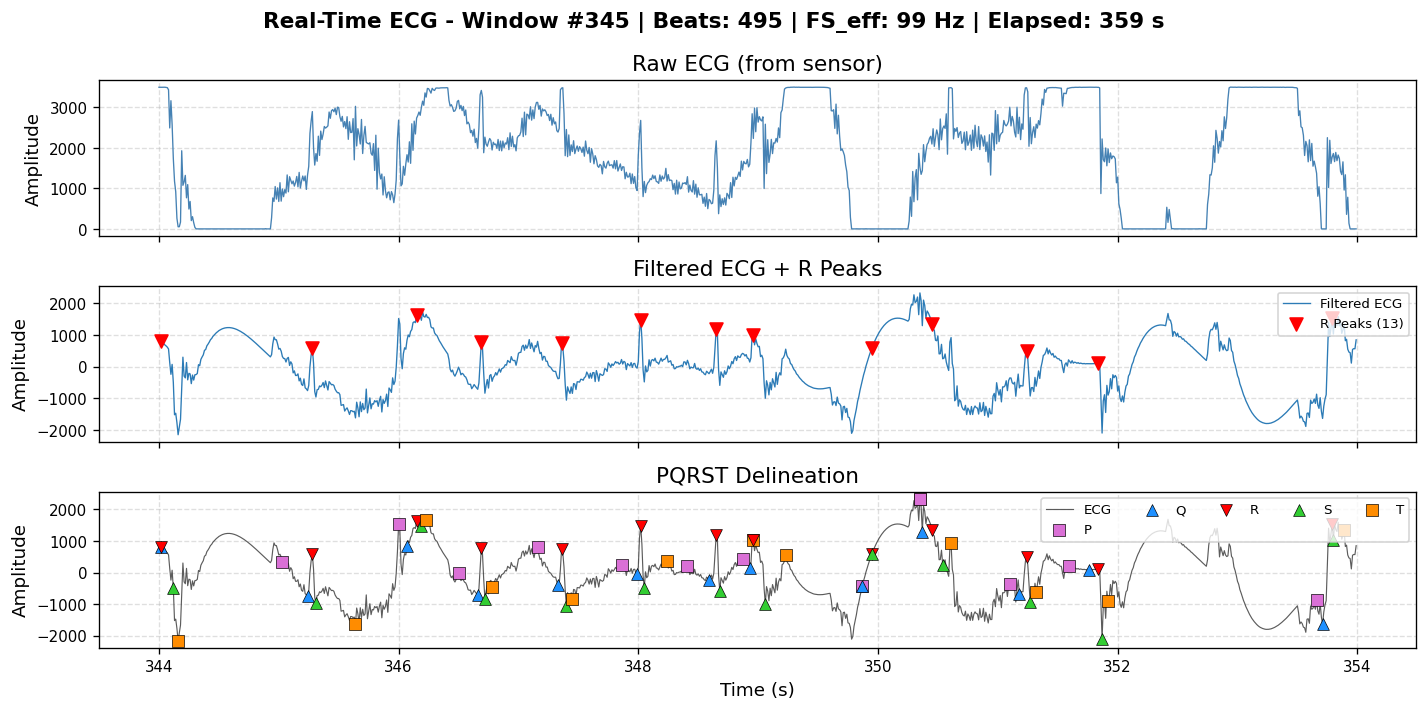

[Win  345] Beats: 495 | New: 1 | HR: 95 BPM | SNR: 25 dB | P2P: 4480.643 | Samples: 35400 | Dropped: 153 | Errors: 0 | Effective FS: 98.3 Hz | Elapsed: 360.1 s


In [ ]:
# ==========================================================
# MAIN REAL-TIME LOOP — Run this cell to start continuous processing
# ==========================================================

import csv
import os

# — Instantiate all pipeline components
ring_buf = RingBuffer(capacity=BUFFER_SAMPLES, fs=FS)

filter_bank = RealtimeFilterBank(
    fs=FS,
    powerline_freq=POWERLINE_FREQ,
    notch_q=NOTCH_Q,
    bp_low=BP_LOW,
    bp_high=BP_HIGH,
    bp_order=BP_ORDER
)

rpeak_detector = RealtimeRPeakDetector(fs=FS)
event_registry = GlobalEventRegistry(
    fs=FS,
    duplicate_tol_s=DUPLICATE_TOL_S
)
serial_stats = SerialStats()

# Also maintain a filtered ring buffer for visualization
ring_buf_filtered = RingBuffer(capacity=BUFFER_SAMPLES, fs=FS)

# — Initialise CSV log files with headers
SUMMARY_CSV = "realtime_ecg_summary.csv"
EVENTS_CSV = "realtime_ecg_events.csv"
QUALITY_CSV = "realtime_ecg_quality_log.csv"

with open(SUMMARY_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "Beat#", "P_time_s", "Q_time_s", "R_time_s",
        "S_time_s", "T_time_s",
        "RR_ms", "HR_BPM", "Tier", "Status"
    ])

with open(EVENTS_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "Event_Type", "Global_Sample_Idx",
        "Time_s", "Amplitude"
    ])

with open(QUALITY_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "Window#", "Timestamp_s",
        "P2P", "RMS", "Baseline", "SNR_dB",
        "Is_Clipped", "N_RPeaks_Window",
        "Eff_FS_Hz", "Dropped_Lines"
    ])

print("✓ CSV files initialised:")
print(f"  {SUMMARY_CSV}")
print(f"  {EVENTS_CSV}")
print(f"  {QUALITY_CSV}")

# — Open serial port
ser = open_serial(COM_PORT, BAUD_RATE, SERIAL_TIMEOUT)

# — Processing state variables
samples_since_last_process = 0
window_counter = 0
total_new_beats = 0

# Store quality log in memory too for final analysis
quality_log = []

print("\n" + "=" * 65)
print("  STARTING REAL-TIME ECG ACQUISITION AND PROCESSING")
print("  Press Jupyter STOP button (■) or Ctrl+C to end.")
print("=" * 65 + "\n")

try:
    while True:

        # — Step A: Read one line from serial
        try:
            raw_line = ser.readline()
        except serial.SerialException as e:
            serial_stats.record_error()
            print(f"[Serial Error] {e}")
            continue

        except OSError as e:
            serial_stats.record_error()
            print(f"[OS Error] {e}")
            continue

        # — Step B: Parse the sample
        sample = parse_sample(raw_line)

        if sample is None:
            serial_stats.record_drop()
            continue

        # Optional ADC conversion
        if ENABLE_ADC_CONVERSION:
            sample = adc_to_mv(sample)

        # — Step C: Append to ring buffer
        ring_buf.append(sample)
        serial_stats.record_sample()

        # Also filter and store in filtered buffer for visualization
        filtered_sample = filter_bank.process_sample(sample)
        ring_buf_filtered.append(filtered_sample)

        samples_since_last_process += 1

        # — Step D: Trigger processing every STEP_DURATION_S
        if samples_since_last_process < STEP_SAMPLES:
            continue

        # Check if we have enough data for a full window
        if ring_buf_filtered.filled < WINDOW_SAMPLES:
            samples_since_last_process = 0
            continue

        samples_since_last_process = 0
        window_counter += 1

        # — Step E: Extract the latest window
        ecg_window_filtered = ring_buf_filtered.get_window(WINDOW_SAMPLES)
        ecg_window_raw = ring_buf.get_window(WINDOW_SAMPLES)

        global_offset = ring_buf_filtered.get_global_offset(
            WINDOW_SAMPLES
        )

        window_time = ring_buf_filtered.get_time_axis(
            WINDOW_SAMPLES
        )

        # — Step F: Signal quality assessment
        quality = compute_window_quality(
            ecg_window_filtered,
            FS
        )

        quality_entry = {
            "window": window_counter,
            "timestamp_s": round(ring_buf.count / FS, 2),
            **quality,
            "eff_fs": round(serial_stats.effective_fs, 1),
            "dropped": serial_stats.total_dropped,
        }

        quality_log.append(quality_entry)

        # Write quality to CSV
        with open(QUALITY_CSV, "a", newline="") as f:
            writer = csv.writer(f)

            writer.writerow([
                window_counter,
                quality_entry["timestamp_s"],
                f"{quality['peak_to_peak']:.4f}",
                f"{quality['rms']:.4f}",
                f"{quality['baseline_level']:.4f}",
                f"{quality['snr_db']:.1f}",
                quality["is_clipped"],
                0,  # Will be updated below
                quality_entry["eff_fs"],
                quality_entry["dropped"],
            ])

        # — Step G: R-peak detection
        detections, ecg_integrated, ecg_work = (
            rpeak_detector.detect_in_window(
                ecg_window_filtered,
                global_offset
            )
        )

        n_peaks_this_window = len(detections)

        # — Step H: Add to registry and delineate
        new_beats_this_cycle = []

        # Get local R indices for prev/next context
        local_r_indices = [
            d["local_idx"] for d in detections
        ]

        for i, det in enumerate(detections):

            accepted = event_registry.add_r_peak(
                det["global_idx"],
                det["amplitude"],
                det.get("tier", 1)
            )

            if accepted:

                # Delineate PQRST
                prev_r = (
                    local_r_indices[i - 1]
                    if i > 0 else None
                )

                next_r = (
                    local_r_indices[i + 1]
                    if i < len(detections) - 1 else None
                )

                fid = delineate_beat(
                    ecg_window_filtered,
                    det["local_idx"],
                    FS,
                    prev_r_local=prev_r,
                    next_r_local=next_r
                )

                # Convert fiducials to global indices and store
                for wave in ["P", "Q", "S", "T"]:

                    local_idx = fid.get(wave)

                    global_idx = (
                        global_offset + local_idx
                        if local_idx is not None
                        else None
                    )

                    event_registry.add_fiducial(
                        det["global_idx"],
                        wave,
                        global_idx
                    )

        # — Step I: Get new beats to emit
        new_r_peaks = event_registry.get_new_r_peaks_since()

        if new_r_peaks:

            all_r = event_registry.get_all_r_peaks()

            for rp in new_r_peaks:

                r_gidx = rp['global_idx']
                fids = event_registry.get_beat_fiducials(r_gidx)

                total_new_beats += 1

                # Compute RR and HR
                r_pos_in_all = np.searchsorted(all_r, r_gidx)

                if r_pos_in_all > 0:
                    prev_r_gidx = all_r[r_pos_in_all - 1]

                    rr_s = (r_gidx - prev_r_gidx) / FS
                    rr_ms = rr_s * 1000
                    hr_bpm = 60.0 / rr_s if rr_s > 0 else float('nan')
                else:
                    rr_ms = float('nan')
                    hr_bpm = float('nan')

                # Convert indices to times
                def idx_to_t(idx):
                    return round(idx / FS, 4) if idx is not None else ""

                status = "OK"

                if not np.isnan(rr_ms):
                    if rr_ms < 270:
                        status = "SHORT_RR"
                    elif rr_ms > 2000:
                        status = "LONG_RR"

                # Write to summary CSV
                with open(SUMMARY_CSV, "a", newline="") as f:
                    writer = csv.writer(f)

                    writer.writerow([
                        total_new_beats,
                        idx_to_t(fids.get('P')),
                        idx_to_t(fids.get('Q')),
                        idx_to_t(r_gidx),
                        idx_to_t(fids.get('S')),
                        idx_to_t(fids.get('T')),
                        f"{rr_ms:.1f}" if not np.isnan(rr_ms) else "",
                        f"{hr_bpm:.1f}" if not np.isnan(hr_bpm) else "",
                        rp.get('tier', ''),
                        status,
                    ])

                # Write individual events to events CSV
                with open(EVENTS_CSV, "a", newline="") as f:
                    writer = csv.writer(f)

                    writer.writerow([
                        "R",
                        r_gidx,
                        idx_to_t(r_gidx),
                        f"{rp['amplitude']:.4f}"
                    ])

                    for wave in ['P', 'Q', 'S', 'T']:
                        w_idx = fids.get(wave)

                        if w_idx is not None:
                            writer.writerow([
                                wave,
                                w_idx,
                                idx_to_t(w_idx),
                                ""
                            ])

            event_registry.mark_emitted_up_to(
                new_r_peaks[-1]['global_idx']
            )

        # — Step J: Live visualization
        if window_counter % 3 == 0 or window_counter <= 3:

            # Update plot every 3 windows (or first 3)
            try:
                clear_output(wait=True)

                fig, axes = plt.subplots(
                    3, 1,
                    figsize=(12, 6),
                    sharex=True
                )

                fig.suptitle(
                    f"Real-Time ECG - Window #{window_counter} | "
                    f"Beats: {event_registry.n_beats} | "
                    f"FS_eff: {serial_stats.effective_fs:.0f} Hz | "
                    f"Elapsed: {serial_stats.elapsed:.0f} s",
                    fontsize=13,
                    fontweight='bold'
                )

                t_ax = window_time

                # Panel 1: Raw ECG
                axes[0].plot(
                    t_ax,
                    ecg_window_raw,
                    color='steelblue',
                    lw=0.8
                )

                axes[0].set_title('Raw ECG (from sensor)')
                axes[0].set_ylabel('Amplitude')
                axes[0].grid(True, ls='--', alpha=0.4)

                # Panel 2: Cleaned ECG + R peaks
                axes[1].plot(
                    t_ax,
                    ecg_window_filtered,
                    color='#2c7bb6',
                    lw=0.8,
                    label='Filtered ECG'
                )

                # Overlay R peaks that fall in this window
                all_r_global = event_registry.get_all_r_peaks()

                window_start_g = global_offset
                window_end_g = global_offset + WINDOW_SAMPLES

                r_in_window = all_r_global[
                    (all_r_global >= window_start_g) &
                    (all_r_global < window_end_g)
                ]

                if len(r_in_window) > 0:

                    r_local = r_in_window - global_offset

                    valid = r_local < len(ecg_window_filtered)
                    r_local = r_local[valid]

                    r_times = (
                        t_ax[r_local]
                        if len(r_local) > 0 else []
                    )

                    r_amps = (
                        ecg_window_filtered[r_local]
                        if len(r_local) > 0 else []
                    )

                    if len(r_local) > 0:
                        axes[1].scatter(
                            r_times,
                            r_amps,
                            color='red',
                            s=60,
                            zorder=5,
                            marker='v',
                            label=f'R Peaks ({len(r_local)})'
                        )

                axes[1].set_title('Filtered ECG + R Peaks')
                axes[1].set_ylabel('Amplitude')
                axes[1].legend(loc='upper right', fontsize=8)
                axes[1].grid(True, ls='--', alpha=0.4)

                # # Panel 3: Integrated signal + threshold
                # if ecg_integrated is not None:

                #     int_time = t_ax[:len(ecg_integrated)]

                #     axes[2].plot(
                #         int_time,
                #         ecg_integrated,
                #         color='#1a9641',
                #         lw=0.8,
                #         label='Integrated'
                #     )

                #     if rpeak_detector.threshold is not None:
                #         axes[2].axhline(
                #             rpeak_detector.threshold,
                #             color='orange',
                #             ls='--',
                #             lw=1.2,
                #             label=f'Threshold ({rpeak_detector.threshold:.4f})'
                #         )

                # axes[2].set_title(
                #     'Pan-Tompkins Integrated Signal + Adaptive Threshold'
                # )
                # axes[2].set_ylabel('Integrated')
                # axes[2].legend(loc='upper right', fontsize=8)
                # axes[2].grid(True, ls='--', alpha=0.4)

                # Panel 4: PQRST overlay
                axes[2].plot(
                    t_ax,
                    ecg_window_filtered,
                    color='#333333',
                    lw=0.7,
                    alpha=0.8,
                    label='ECG'
                )

                COLORS = {
                    'P': 'orchid',
                    'Q': 'dodgerblue',
                    'R': 'red',
                    'S': 'limegreen',
                    'T': 'darkorange'
                }

                MRKRS = {
                    'P': 's',
                    'Q': '^',
                    'R': 'v',
                    'S': '^',
                    'T': 's'
                }

                for r_g in r_in_window:

                    fids = event_registry.get_beat_fiducials(int(r_g))

                    for wave in ['P', 'Q', 'R', 'S', 'T']:

                        if wave == 'R':
                            g_idx = int(r_g)
                        else:
                            g_idx = fids.get(wave)

                        if g_idx is not None:

                            l_idx = g_idx - global_offset

                            if 0 <= l_idx < len(ecg_window_filtered):

                                axes[2].scatter(
                                    t_ax[l_idx],
                                    ecg_window_filtered[l_idx],
                                    color=COLORS[wave],
                                    s=50,
                                    zorder=5,
                                    marker=MRKRS[wave],
                                    edgecolors='black',
                                    linewidths=0.4
                                )

                # Legend entries
                for w in ['P', 'Q', 'R', 'S', 'T']:
                    axes[2].scatter(
                        [],
                        [],
                        color=COLORS[w],
                        marker=MRKRS[w],
                        s=50,
                        label=w,
                        edgecolors='black',
                        linewidths=0.4
                    )

                axes[2].set_title('PQRST Delineation')
                axes[2].set_xlabel('Time (s)')
                axes[2].set_ylabel('Amplitude')
                axes[2].legend(
                    loc='upper right',
                    ncol=5,
                    fontsize=8
                )
                axes[2].grid(True, ls='--', alpha=0.4)

                plt.tight_layout()
                plt.show()

            except Exception as plot_err:
                print(f"[Plot warning] {plot_err}")

        # — Step K: Print live status
        hr_arr = event_registry.get_heart_rates()

        hr_str = (
            f"{np.nanmean(hr_arr):.0f}"
            if len(hr_arr) > 0
            else "---"
        )

        diag = ""

        if n_peaks_this_window == 0:
            diag = " • " + diagnose_detection_failure(
                quality,
                0,
                FS,
                WINDOW_SAMPLES
            ).replace("\n", " | ")

        print(
            f"[Win {window_counter:>4}] "
            f"Beats: {event_registry.n_beats} | "
            f"New: {len(new_r_peaks)} | "
            f"HR: {hr_str} BPM | "
            f"SNR: {quality['snr_db']:.0f} dB | "
            f"P2P: {quality['peak_to_peak']:.3f} | "
            f"{serial_stats.summary()}"
            f"{diag}"
        )

except KeyboardInterrupt:
    print("\n\n" + "=" * 65)
    print(" ACQUISITION STOPPED BY USER (KeyboardInterrupt)")
    print("=" * 65)

finally:
    # Clean up
    try:
        ser.close()
        print("✓ Serial port closed.")
    except Exception:
        pass

# — Final summary ————————————————————————————————————————————————————————
    print(f"\n  Total windows processed : {window_counter}")
    print(f"  Total beats detected   : {event_registry.n_beats}")
    print(f"  Serial stats           : {serial_stats.summary()}")

    hr_final = event_registry.get_heart_rates()
    rr_final = event_registry.get_rr_intervals()
    if len(hr_final) > 0:
        print(f"  Mean HR                : {np.nanmean(hr_final):.1f} BPM")
        print(f"  Mean RR                : {np.nanmean(rr_final)*1000:.1f} ms")

    print(f"\n  CSV files written:")
    for csv_f in [SUMMARY_CSV, EVENTS_CSV, QUALITY_CSV]:
        if os.path.exists(csv_f):
            size = os.path.getsize(csv_f)
            print(f"    {csv_f} ({size} bytes)")
    print("\n" + "=" * 65)

## Section 11 — Live Visualization Utilities
The live plot is generated inside the main loop (Section 10, Step 3). This section 
provides an additional standalone function to render the latest window at any 
time after the loop has stopped, using data still in the ring buffers.

This is useful for post-hoc inspection without re-running the acquisition.

In [ ]:
def plot_latest_window(ring_buf_f, ring_buf_r, event_reg, fs, 
                       window_samples, save_path=None):
    """
    Plot the latest window from the ring buffers with all PQRST annotations.
    Can be called after the main loop has stopped.
    """
    if ring_buf_f.filled < window_samples:
        print(f"[INFO] Not enough data in buffer to plot a full window.")
        return

    ecg_filt = ring_buf_f.get_window(window_samples)
    ecg_raw = ring_buf_r.get_window(window_samples)
    g_offset = ring_buf_f.get_global_offset(window_samples)
    t_ax = ring_buf_f.get_time_axis(window_samples)

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    fig.suptitle('Latest Window - Post-Acquisition View', fontsize=14, fontweight='bold')
    
    # Raw
    axes[0].plot(t_ax, ecg_raw, color='steelblue', lw=0.8, label='Raw ECG')
    axes[0].set_title('Raw ECG'); axes[0].set_ylabel('Amplitude')
    axes[0].legend(loc='upper right'); axes[0].grid(True, ls='--', alpha=0.4)

    # Filtered + PQRST
    axes[1].plot(t_ax, ecg_filt, color='#333', lw=0.7, alpha=0.8, label='Filtered ECG')

    COLORS = {'P': 'orchid', 'Q': 'dodgerblue', 'R': 'red',
            'S': 'limegreen', 'T': 'darkorange'}
    MRKRS = {'P': 's', 'Q': '^', 'R': 'v', 'S': '^', 'T': 's'}

    all_r = event_reg.get_all_r_peaks()
    g_end = g_offset + window_samples
    r_in_win = all_r[(all_r >= g_offset) & (all_r < g_end)]

    for rg in r_in_win:
        fids = event_reg.get_beat_fiducials(int(rg))
        for w in ['P', 'Q', 'R', 'S', 'T']:
            gidx = int(rg) if w == 'R' else fids.get(w)
            if gidx is not None:
                lidx = gidx - g_offset
                if 0 <= lidx < len(ecg_filt):
                    axes[1].scatter(t_ax[lidx], ecg_filt[lidx],
                                    color=COLORS[w], s=55, zorder=5,
                                    marker=MRKRS[w], edgecolors='black', linewidths=0.4)

    for w in ['P', 'Q', 'R', 'S', 'T']:
        axes[1].scatter([], [], color=COLORS[w], marker=MRKRS[w],
                        s=50, label=w, edgecolors='black', linewidths=0.4)
    
    # ... continuing from the scatter plotting loop ...

    axes[1].set_title('Filtered ECG + PQRST Delineation')
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Amplitude')
    axes[1].legend(loc='upper right', ncol=5, fontsize=9)
    axes[1].grid(True, ls='--', alpha=0.4)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved: {save_path}")
    plt.show()


    # --- Call it (safe to run after the main loop) ---
    try:
        plot_latest_window(ring_buf_filtered, ring_buf, event_registry, FS,
                        WINDOW_SAMPLES, save_path="latest_window_pqrst.png")
    except NameError:
        print("[INFO] Run the main loop (Section 10) first.")

## Section 12 — Per-Beat Table and Interval summary

Run this cell **after stopping the main loop** to see the accumulated results.

All values are computed from **real sensor data only**,

In [ ]:
# #############################################################
# PER-BEAT SUMMARY TABLE
# #############################################################
try:
    all_r_peaks = event_registry.get_all_r_peaks()
    rr_intervals = event_registry.get_rr_intervals()
    hr_bpm_arr = event_registry.get_heart_rates()
except NameError:
    print("[ERROR] Run the main loop first (Section 10).")
    all_r_peaks = np.array([])
    rr_intervals = np.array([])
    hr_bpm_arr = np.array([])

if len(all_r_peaks) == 0:
    print("No beats detected. Nothing to display.")
else:
    rows = []
    for i, r_g in enumerate(all_r_peaks):
        fids = event_registry.get_beat_fiducials(int(r_g))
        
        def idx_to_time(idx):
            return round(idx / FS, 4) if idx is not None else float('nan')
        
        rr_ms = rr_intervals[i - 1] * 1000 if i > 0 and i - 1 < len(rr_intervals) else float('nan')
        hr = hr_bpm_arr[i - 1] if i > 0 and i - 1 < len(hr_bpm_arr) else float('nan')

        rows.append({
            'Beat#': i + 1,
            'P (s)': idx_to_time(fids.get('P')),
            'Q (s)': idx_to_time(fids.get('Q')),
            'R (s)': idx_to_time(int(r_g)),
            'S (s)': idx_to_time(fids.get('S')),
            'T (s)': idx_to_time(fids.get('T')),
            'RR (ms)': round(rr_ms, 1) if not np.isnan(rr_ms) else float('nan'),
            'HR (BPM)': round(hr, 1) if not np.isnan(hr) else float('nan'),
        })

    df_beats = pd.DataFrame(rows)
    pd.set_option('display.float_format', '{:.4f}'.format)
    pd.set_option('display.max_rows', 100)
    pd.set_option('display.width', 140)
    print("\n" + "-" * 85)
    print(" PER-BEAT SUMMARY TABLE ")
    print("-" * 85)
    print(df_beats.to_string(index=False))
    print(f"\n Total beats: {len(rows)}")

    # ----INTERVAL SUMMARY------------------------------------------------------------------------------

    print("\n" + "-" * 65)
    print(" PQRST INTERVAL SUMMARY (mean ± std)")
    print("-" * 65)

    def interval_stats(name, vals_ms, lo, hi):
        v = [x for x in vals_ms if not np.isnan(x) and x > 0]
        if not v:
            print(f" {name:<22}: Not computed")
            return
        m, s = np.mean(v), (np.std(v, ddof=1) if len(v) > 1 else 0.0)
        ok = '✓' if lo <= m <= hi else 'Δ'
        print(f" {name:<22}: {m:7.1f} ± {s:5.1f} ms  (normal: {lo}-{hi} ms) {ok}")

    # RR
    interval_stats("RR interval", list(rr_intervals * 1000), 600, 1000)

    # PR: P to R
    pr_ms = []
    for i, r_g in enumerate(all_r_peaks):
        fid = event_registry.get_beat_fiducials(int(r_g))
        p_idx = fid.get('P')
        if p_idx is not None:
            pr_ms.append((int(r_g) - p_idx) / FS * 1000)
    interval_stats("PR interval (P->R)", pr_ms, 120, 200)

    # QRS: Q to S
    qrs_ms = []
    for rg in all_r_peaks:
        fid = event_registry.get_beat_fiducials(int(rg))
        q, s = fid.get('Q'), fid.get('S')
        if q is not None and s is not None and s > q:
            qrs_ms.append((s - q) / FS * 1000)
    interval_stats("QRS duration (Q->S)", qrs_ms, 60, 120)

    # QT: Q/R to T
    qt_ms = []
    for rg in all_r_peaks:
        fid = event_registry.get_beat_fiducials(int(rg))
        q, t = fid.get('Q'), fid.get('T')
        ref = q if q is not None else int(rg)
        if t is not None and t > ref:
            qt_ms.append((t - ref) / FS * 1000)
    interval_stats("QT interval (Q->T)", qt_ms, 300, 480)

    # ST: S to T
    st_ms = []
    for rg in all_r_peaks:
        fid = event_registry.get_beat_fiducials(int(rg))
        s_idx, t_idx = fid.get('S'), fid.get('T')
        if s_idx is not None and t_idx is not None and t_idx > s_idx:
            st_ms.append((t_idx - s_idx) / FS * 1000)
    interval_stats("ST segment (S->T)", st_ms, 80, 320)

    # ---- HRV STATISTICS---------------------------------------
    print("\n" + "-" * 65)
    print(" HEART RATE VARIABILITY (HRV)")
    print("-" * 65)

    if len(rr_intervals) >= 2:
        rr_ms_arr = rr_intervals * 1000
        valid_rr = rr_ms_arr[(rr_ms_arr > 270) & (rr_ms_arr < 2000)]

        if len(valid_rr) >= 2:
            sdnn = float(np.std(valid_rr, ddof=1))
            rmssd = float(np.sqrt(np.mean(np.diff(valid_rr) ** 2)))
            nn50 = int(np.sum(np.abs(np.diff(valid_rr)) > 50))
            pnn50 = 100.0 * nn50 / (len(valid_rr) - 1) if len(valid_rr) > 1 else 0

            print(f" Mean RR   : {np.mean(valid_rr):.1f} ms")
            print(f" SDNN      : {sdnn:.1f} ms")
            print(f" RMSSD     : {rmssd:.1f} ms")
            print(f" NN50      : {nn50}")
            print(f" pNN50     : {pnn50:.1f} %")
            print(f" Mean HR   : {np.nanmean(hr_bpm_arr):.1f} BPM")
            print(f" Min HR    : {np.nanmin(hr_bpm_arr):.1f} BPM")
            print(f" Max HR    : {np.nanmax(hr_bpm_arr):.1f} BPM")
        else:
            print(" Insufficient valid RR intervals for HRV analysis.")
    else:
        print(" Fewer than 2 RR intervals - cannot compute HRV.")

    print("-" * 65)

## Section 13 — Export Outputs

Confirms that all csv files have been written and generates final publication-quality figures 
from the accumulated data.

In [ ]:
# Section 13 - Export Outputs
# Confirms that all csv files have been verified and generates final publication-quality figures
# from the accumulated data.

import os

print("-" * 65)
print(" OUTPUT FILES")
print("-" * 65)

for csv_file in [SUMMARY_CSV, EVENTS_CSV, QUALITY_CSV]:
    if os.path.exists(csv_file):
        size = os.path.getsize(csv_file)
        # Count rows
        with open(csv_file, 'r') as f:
            n_rows = sum(1 for _ in f) - 1  # Subtract header
        print(f" ✓ {csv_file:<40} {size:>8} bytes, {n_rows} rows")
    else:
        print(f" X {csv_file} - NOT FOUND")

# --- Generate final summary figure ---
try:
    all_r = event_registry.get_all_r_peaks()
    if len(all_r) >= 2:
        rr_s = np.diff(all_r) / FS
        rr_ms_plot = rr_s * 1000
        hr_plot = 60.0 / rr_s

        fig, axes = plt.subplots(2, 1, figsize=(14, 7))
        fig.suptitle('Heart Rate and RR Interval Trends - Full Session',
                     fontsize=14, fontweight='bold')

        beat_nums = np.arange(1, len(rr_ms_plot) + 1)

        axes[0].plot(beat_nums, rr_ms_plot, 'o-', color='#2c7bb6', markersize=4, lw=1)
        axes[0].set_title('RR Interval Tachogram')
        axes[0].set_ylabel('RR (ms)')
        axes[0].set_xlabel('Beat number')
        axes[0].grid(True, ls='--', alpha=0.4)
        axes[0].axhline(np.mean(rr_ms_plot), color='red', ls='--', lw=1,
                        label=f'Mean: {np.mean(rr_ms_plot):.0f} ms')
        axes[0].legend()

        axes[1].plot(beat_nums, hr_plot, 'o-', color='#d7191c', markersize=4, lw=1)
        axes[1].set_title('Instantaneous Heart Rate')
        axes[1].set_ylabel('HR (BPM)')
        axes[1].set_xlabel('Beat number')
        axes[1].grid(True, ls='--', alpha=0.4)
        axes[1].axhline(np.nanmean(hr_plot), color='blue', ls='--', lw=1,
                        label=f'Mean: {np.nanmean(hr_plot):.0f} BPM')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig('hr_rr_trends.png', dpi=150, bbox_inches='tight')
        plt.savefig('hr_rr_trends.pdf', dpi=150, bbox_inches='tight')
        plt.show()
        print("\n ✓ hr_rr_trends.png / .pdf saved")
    else:
        print("\n [INFO] Not enough beats to generate trend plots.")
except NameError:
        print("\n [INFO] Run the main loop first.")

# --- Generate latest window figure ---
try:
    plot_latest_window(ring_buf_filtered, ring_buf, event_registry, FS,
                        WINDOW_SAMPLES, save_path="final_pqrst_window.png")
    print(" ✓ final_pqrst_window.png saved")
except NameError:
    print(" [INFO] Run the main loop first.")

print("\n" + "-" * 65)

## THANKYOUU!!